In [ ]:
from src.inverse_pinn import InversePINN
from src.inverse_pinn_trainer import InversePINNTrainer

import numpy as np
from analytical_solution import analytical


np.random.seed(42)
# I recommend starting at t=0 so IC is meaningful for a physical initial condition
t_ex = np.linspace(0.0, 4.7, 100)
x_ex = analytical(t_ex, zeta=0.3, omega_n=5.0) + 0.05 * np.random.randn(len(t_ex))

observed_data = np.vstack((t_ex, x_ex)).T


trainer = InversePINNTrainer(n_epochs=2000)



trainer.train(observed_data=observed_data,n_epochs=80)

Epoch: 0, Total Loss: 27.78, Physics Loss: 0.23, Data Loss: 0.07, IC Loss: 2.69, Zeta: 0.20100, Omega: 2.99900
Epoch: 10, Total Loss: 20.31, Physics Loss: 1.40, Data Loss: 0.06, IC Loss: 1.83, Zeta: 0.20285, Omega: 2.99030
Epoch: 20, Total Loss: 17.07, Physics Loss: 5.28, Data Loss: 0.10, IC Loss: 1.08, Zeta: 0.21313, Omega: 2.97990
Epoch: 30, Total Loss: 13.59, Physics Loss: 4.99, Data Loss: 0.09, IC Loss: 0.77, Zeta: 0.22511, Omega: 2.96795
Epoch: 40, Total Loss: 9.73, Physics Loss: 4.52, Data Loss: 0.08, IC Loss: 0.44, Zeta: 0.23813, Omega: 2.95609
Epoch: 50, Total Loss: 6.00, Physics Loss: 3.39, Data Loss: 0.06, IC Loss: 0.20, Zeta: 0.25190, Omega: 2.94515
Epoch: 60, Total Loss: 3.98, Physics Loss: 2.88, Data Loss: 0.05, IC Loss: 0.06, Zeta: 0.26551, Omega: 2.93577
Epoch: 70, Total Loss: 3.66, Physics Loss: 2.53, Data Loss: 0.05, IC Loss: 0.06, Zeta: 0.27790, Omega: 2.92740


(InversePINN(
   (net): Sequential(
     (0): Linear(in_features=1, out_features=64, bias=True)
     (1): SiLU()
     (2): Linear(in_features=64, out_features=64, bias=True)
     (3): SiLU()
     (4): Linear(in_features=64, out_features=64, bias=True)
     (5): SiLU()
     (6): Linear(in_features=64, out_features=1, bias=True)
   )
 ),
 <diagnostics_logger.DiagnosticsLogger at 0x14c2f0a00>)

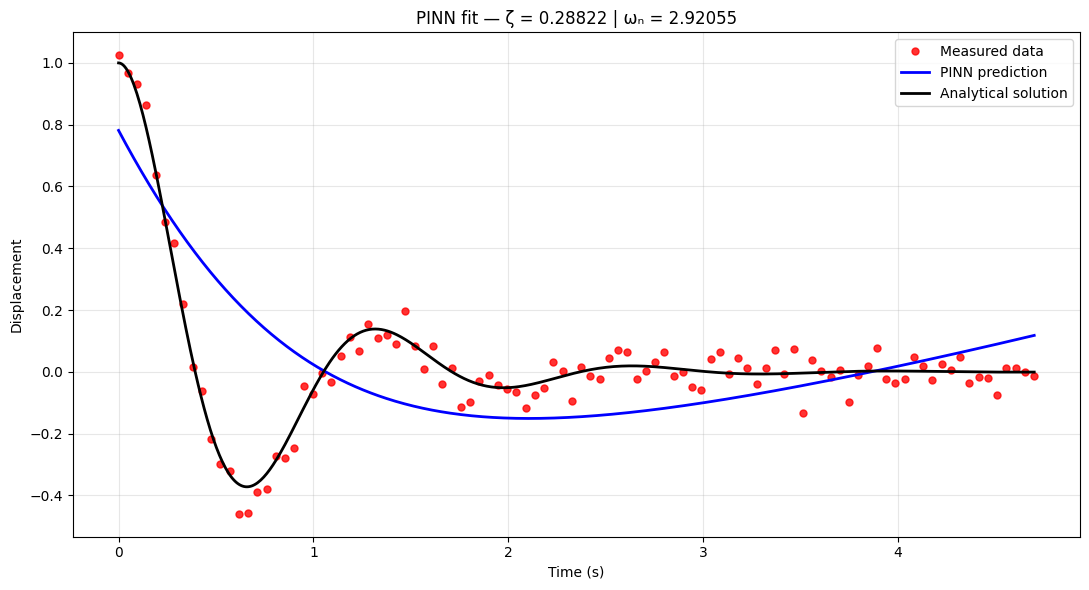

In [4]:
trainer.plot_phys_vs_data(observed_data=observed_data,analytical_data=True)

In [ ]:

from src.inverse_pinn import train_inverse_pinn_from_data


ImportError: cannot import name 'train_inverse_pinn_from_data' from 'src' (/Users/idebono/Desktop/PHYSICS/PINN_tutorial/src.py)

Training PINN on 100 measured points for 10 epochs... (device=cpu)
Epoch      1 | loss=2.931e+01 | Lp=1.753e+00 | Ld=6.506e-02 | Li=2.690e+00 | ζ=0.30100 | ωₙ=4.99900
Epoch      2 | loss=2.739e+01 | Lp=5.537e-01 | Ld=6.165e-02 | Li=2.622e+00 | ζ=0.30066 | ωₙ=4.99814
Epoch      3 | loss=2.617e+01 | Lp=4.915e-02 | Ld=5.932e-02 | Li=2.553e+00 | ζ=0.30010 | ωₙ=4.99745
Epoch      4 | loss=2.552e+01 | Lp=1.158e-01 | Ld=5.789e-02 | Li=2.483e+00 | ζ=0.30043 | ωₙ=4.99686
Epoch      5 | loss=2.527e+01 | Lp=5.619e-01 | Ld=5.712e-02 | Li=2.414e+00 | ζ=0.30103 | ωₙ=4.99621
Epoch      6 | loss=2.519e+01 | Lp=1.129e+00 | Ld=5.667e-02 | Li=2.350e+00 | ζ=0.30173 | ωₙ=4.99547
Epoch      7 | loss=2.505e+01 | Lp=1.547e+00 | Ld=5.631e-02 | Li=2.294e+00 | ζ=0.30250 | ωₙ=4.99465
Epoch      8 | loss=2.493e+01 | Lp=1.893e+00 | Ld=5.592e-02 | Li=2.248e+00 | ζ=0.30332 | ωₙ=4.99377
Epoch      9 | loss=2.469e+01 | Lp=2.018e+00 | Ld=5.552e-02 | Li=2.211e+00 | ζ=0.30420 | ωₙ=4.99285
Epoch     10 | loss=2.454e+01 | L

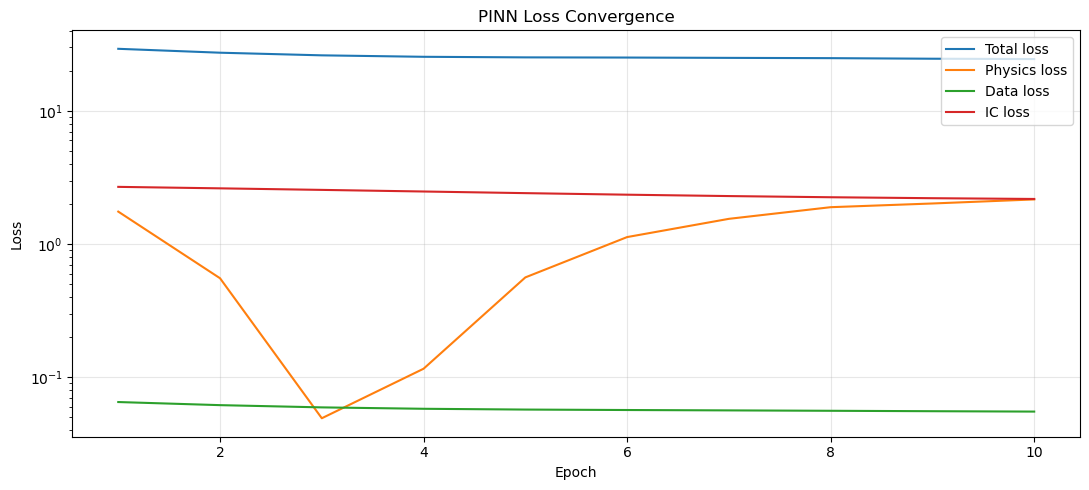

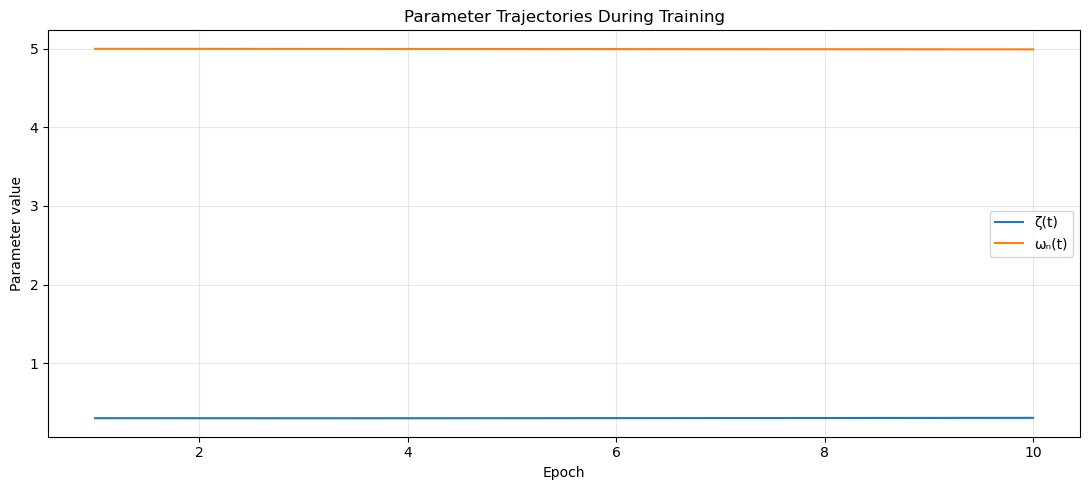

NameError: name 'to_t_hat' is not defined

In [ ]:


model, diag = train_inverse_pinn_from_data(
    observed_data,
    n_epochs=10,      # increase if still underfitting (try 3k-10k)
    colloc_points=8000,
    seed=42,
    use_lbfgs=False,
    zeta_init=0.3, omega_n_init=5.0
)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam, LBFGS

# Helper diagnostics logger (assumed from original context)
class DiagnosticsLogger:
    def __init__(self):
        self.history = {
            'epoch': [], 'loss': [], 'Lp': [], 'Ld': [], 'Li': [],
            'zeta': [], 'omega_n': []
        }

    def record(self, epoch, loss, Lp, Ld, Li, zeta, omega_n):
        self.history['epoch'].append(epoch)
        self.history['loss'].append(loss)
        self.history['Lp'].append(Lp)
        self.history['Ld'].append(Ld)
        self.history['Li'].append(Li)
        self.history['zeta'].append(zeta)
        self.history['omega_n'].append(omega_n)

    def plot_all(self):
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(2, 2, figsize=(12, 8))

        axs[0, 0].semilogy(self.history['epoch'], self.history['loss'], label='Total loss')
        axs[0, 0].set_xlabel('Epoch')
        axs[0, 0].set_ylabel('Loss')
        axs[0, 0].grid(alpha=0.3)
        axs[0, 0].legend()

        axs[0, 1].semilogy(self.history['epoch'], self.history['Lp'], label='Physics loss')
        axs[0, 1].semilogy(self.history['epoch'], self.history['Ld'], label='Data loss')
        axs[0, 1].semilogy(self.history['epoch'], self.history['Li'], label='IC loss')
        axs[0, 1].set_xlabel('Epoch')
        axs[0, 1].set_ylabel('Component losses')
        axs[0, 1].grid(alpha=0.3)
        axs[0, 1].legend()

        axs[1, 0].plot(self.history['epoch'], self.history['zeta'])
        axs[1, 0].set_xlabel('Epoch')
        axs[1, 0].set_ylabel('ζ (damping ratio)')
        axs[1, 0].grid(alpha=0.3)

        axs[1, 1].plot(self.history['epoch'], self.history['omega_n'])
        axs[1, 1].set_xlabel('Epoch')
        axs[1, 1].set_ylabel('ωₙ (natural frequency)')
        axs[1, 1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


# ---------------------------
# Inverse PINN Class
# ---------------------------
class InversePINN(torch.nn.Module):
    def __init__(self, layers=[1, 50, 50, 50, 50, 1], activation=torch.nn.Tanh):
        super().__init__()
        
        # Learnable parameters: damping ratio ζ and natural frequency ωₙ
        # Initialized with reasonable positive values
        self.zeta = torch.nn.Parameter(torch.tensor(0.5, dtype=torch.float64))
        self.omega_n = torch.nn.Parameter(torch.tensor(3.0, dtype=torch.float64))
        
        # Neural network for displacement x(t̂)
        net_layers = []
        for i in range(len(layers) - 2):
            net_layers.append(torch.nn.Linear(layers[i], layers[i+1]))
            net_layers.append(activation())
        net_layers.append(torch.nn.Linear(layers[-2], layers[-1]))
        self.net = torch.nn.Sequential(*net_layers)

    def forward(self, t_hat):
        return self.net(t_hat)


    def train_from_data(
        self,
        t_data,
        x_data,
        n_epochs=2000,
        colloc_points=8000,
        seed=42,
        use_lbfgs=True,
        plot_solution=True,
        analytical_solution=None,  # Optional callable analytical(t_phys) for comparison
    ):
        """
        Train the inverse PINN using measured time and displacement data.
        
        Parameters
        ----------
        t_data : array-like
            Physical time values (1D).
        x_data : array-like
            Measured displacement values (1D, same length as t_data).
        n_epochs : int
            Number of Adam training epochs.
        colloc_points : int
            Number of collocation points for physics loss.
        seed : int
            Random seed for reproducibility.
        use_lbfgs : bool
            Whether to refine with L-BFGS after Adam.
        plot_solution : bool
            Whether to plot final fit vs data and analytical (if provided).
        analytical_solution : callable or None
            Optional analytical solution function analytical(t_phys_array) -> x_array.
        
        Returns
        -------
        diagnostics : DiagnosticsLogger
            Training history and plotting utility.
        """
        # Reproducibility and device
        torch.manual_seed(seed)
        np.random.seed(seed)
        torch.set_default_dtype(torch.float64)
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)

        # Convert data to tensors
        t_raw = torch.tensor(np.asarray(t_data).reshape(-1, 1), dtype=torch.float64, device=device)
        x_measured = torch.tensor(np.asarray(x_data).reshape(-1, 1), dtype=torch.float64, device=device)

        # Physical time bounds
        t_min = float(t_raw.min().item())
        t_max = float(t_raw.max().item())
        if t_max == t_min:
            raise ValueError("t_data has zero range")

        # Normalization functions: t_hat ∈ [-1, 1]
        def to_t_hat(t_phys):
            return 2.0 * (t_phys - t_min) / (t_max - t_min) - 1.0

        def to_t_phys(t_hat):
            return (t_hat + 1.0) * 0.5 * (t_max - t_min) + t_min

        t_measured = to_t_hat(t_raw).detach()  # No grad needed for data points
        dt_scale = 2.0 / (t_max - t_min)       # d/dt_phys = dt_scale * d/dt_hat

        # Collocation points in normalized time
        def get_collocation(N=colloc_points):
            t = torch.rand(N, 1, device=device, dtype=torch.float64) * 2.0 - 1.0
            return t.requires_grad_(True)

        # PDE residual (second-order damped oscillator)
        def pde_residual(t_hat):
            t_hat = t_hat.clone().requires_grad_(True)
            x = self(t_hat)
            dx_dthat = torch.autograd.grad(x, t_hat, torch.ones_like(x), create_graph=True)[0]
            d2x_dthat2 = torch.autograd.grad(dx_dthat, t_hat, torch.ones_like(dx_dthat), create_graph=True)[0]

            x_t_phys  = dt_scale * dx_dthat
            x_tt_phys = (dt_scale ** 2) * d2x_dthat2

            return x_tt_phys + 2.0 * self.zeta * self.omega_n * x_t_phys + (self.omega_n ** 2) * x

        # Loss components
        def physics_loss():
            t_colloc = get_collocation()
            r = pde_residual(t_colloc)
            return torch.mean(r ** 2)

        def data_loss():
            pred = self(t_measured)
            return torch.mean((pred - x_measured) ** 2)

        def ic_loss():
            # Initial condition enforcement at first measured point
            t0_phys = t_raw[0:1]
            x0_meas = x_measured[0:1]

            # Finite-difference velocity estimate
            if t_raw.shape[0] >= 2:
                t1_phys = t_raw[1:2]
                x1_meas = x_measured[1:2]
                dt_phys = float((t1_phys - t0_phys).item())
                v0_true = (x1_meas - x0_meas) / dt_phys if dt_phys != 0 else torch.zeros_like(x0_meas)
            else:
                v0_true = torch.zeros_like(x0_meas)

            # Model prediction and derivative at t= t0
            t0_hat = to_t_hat(t0_phys).clone().requires_grad_(True)
            x0_pred = self(t0_hat)
            dx_dthat = torch.autograd.grad(x0_pred, t0_hat, torch.ones_like(x0_pred), create_graph=True)[0]
            v0_pred_phys = dt_scale * dx_dthat

            return torch.mean((x0_pred - x0_meas) ** 2) + torch.mean((v0_pred_phys - v0_true) ** 2)

        # Total loss with fixed weights
        def total_loss():
            Lp = physics_loss()
            Ld = data_loss()
            Li = ic_loss()
            w_d = 10.0
            w_i = 10.0
            return Lp + w_d * Ld + w_i * Li, Lp, Ld, Li

        # Optimizer and diagnostics
        optimizer = Adam(self.parameters(), lr=1e-3)
        diag = DiagnosticsLogger()
        print(f"Training InversePINN on {t_raw.shape[0]} data points for {n_epochs} epochs (device={device})")

        # Adam training loop
        for epoch in range(1, n_epochs + 1):
            optimizer.zero_grad()
            loss_total, Lp, Ld, Li = total_loss()
            loss_total.backward()
            optimizer.step()

            diag.record(epoch,
                        float(loss_total.item()),
                        float(Lp.item()),
                        float(Ld.item()),
                        float(Li.item()),
                        float(self.zeta.item()),
                        float(self.omega_n.item()))

            if epoch <= 10 or epoch % max(1, n_epochs // 20) == 0 or epoch == n_epochs:
                print(f"Epoch {epoch:6d} | loss={loss_total.item():.3e} | "
                      f"Lp={Lp.item():.3e} | Ld={Ld.item():.3e} | Li={Li.item():.3e} | "
                      f"ζ={self.zeta.item():.5f} | ωₙ={self.omega_n.item():.5f}")

        # Optional L-BFGS refinement
        if use_lbfgs:
            print("Refining with L-BFGS...")
            lbfgs_opt = LBFGS(self.parameters(), lr=0.2, max_iter=500,
                              tolerance_grad=1e-9, tolerance_change=1e-12, history_size=50)

            def closure():
                lbfgs_opt.zero_grad()
                loss_total, Lp, Ld, Li = total_loss()
                loss_total.backward()
                return loss_total

            for i in range(8):
                lbfgs_opt.step(closure)
                loss_total, Lp, Ld, Li = total_loss()
                print(f" LBFGS step {i+1:2d} | loss={loss_total.item():.3e} | "
                      f"ζ={self.zeta.item():.7f} | ωₙ={self.omega_n.item():.7f}")
                diag.record(n_epochs + i + 1,
                            float(loss_total.item()),
                            float(Lp.item()),
                            float(Ld.item()),
                            float(Li.item()),
                            float(self.zeta.item()),
                            float(self.omega_n.item()))

        print("Training finished.")
        print(f"Identified parameters → ζ = {self.zeta.item():.6f},  ωₙ = {self.omega_n.item():.6f}")

        # Diagnostics plots
        print("\nGenerating diagnostics plots...")
        diag.plot_all()

        # Optional final solution plot
        if plot_solution:
            t_plot_phys = np.linspace(t_min, t_max, 600).reshape(-1, 1)
            t_plot_hat = to_t_hat(torch.tensor(t_plot_phys, dtype=torch.float64, device=device))

            with torch.no_grad():
                x_pred = self(t_plot_hat).cpu().numpy().flatten()

            plt.figure(figsize=(11, 6))
            plt.plot(t_raw.cpu().numpy().flatten(), x_measured.cpu().numpy().flatten(),
                     'ro', label='Measured data', alpha=0.8, markersize=5)
            plt.plot(t_plot_phys.flatten(), x_pred, 'b-', linewidth=2.0, label='Inverse PINN prediction')

            if analytical_solution is not None:
                x_analytical = analytical_solution(t_plot_phys)
                plt.plot(t_plot_phys.flatten(), x_analytical, 'k--', linewidth=2.0, label='Analytical solution')

            plt.xlabel("Time (s)")
            plt.ylabel("Displacement")
            plt.title(f"Inverse PINN fit — ζ = {self.zeta.item():.5f} | ωₙ = {self.omega_n.item():.5f}")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()

        return diag


In [ ]:
import numpy as np
# Example data generation (true ζ=0.3, ωₙ=5.0)
t = np.linspace(0, 5, 100)
true_zeta = 0.3
true_omega = 5.0
x = np.exp(-true_zeta * true_omega * t) * np.sin(true_omega * np.sqrt(1 - true_zeta**2) * t + np.pi/4)

# Create and train
model = InversePINN(layers=[1, 64, 64, 64, 64, 1])
diag = model.train_from_data(
    t_data=t,
    x_data=x,
    n_epochs=8000,
    colloc_points=10000,
    use_lbfgs=False,
    plot_solution=True
)

Training InversePINN on 100 data points for 8000 epochs (device=cpu)


RuntimeError: mat1 and mat2 must have the same dtype, but got Double and Float

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# Set precision
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class PINN(nn.Module):
    def __init__(self, layers=[1, 64, 64, 64, 64, 1]):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 2):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            self.layers.append(nn.Tanh())
        self.layers.append(nn.Linear(layers[-2], layers[-1]))
    
    def forward(self, t):
        for layer in self.layers:
            t = layer(t)
        return t

def pde_residual(model, t,zeta = 0.3,
    omega_n = 5.0):
    t = t.clone().detach().requires_grad_(True)
    x = model(t)
    
    x_t = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, torch.ones_like(x_t), create_graph=True)[0]
    

    return x_tt + 2*zeta*omega_n*x_t + omega_n**2 * x

def ic_loss(model):
    t0 = torch.tensor([[0.0]], device=device, dtype=torch.float64, requires_grad=True)
    
    x0 = model(t0)
    x0_t = torch.autograd.grad(x0, t0, torch.ones_like(x0), create_graph=True)[0]
    
    loss_pos = (x0 - 1.0)**2
    loss_vel = (x0_t - 0.0)**2
    return loss_pos + loss_vel

def train_pinn(epochs = 15000, N = 10000, zeta = 0.3,omega_n = 5.0):
    model = PINN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Collocation points with requires_grad from the start
    
    t_colloc = torch.rand(N, 1, device=device, dtype=torch.float64) * 5.0
    t_colloc.requires_grad = True
    

    start = time.time()
    
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        
        res = pde_residual(model, t_colloc,zeta = zeta,omega_n = omega_n)
        loss_pde = torch.mean(res**2)
        
        loss_ic = ic_loss(model)
        
        loss = loss_pde + 1000 * loss_ic
        loss.backward()
        optimizer.step()
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:5d} | Loss: {loss.item():.2e} | "
                  f"PDE: {loss_pde.item():.2e} | IC: {loss_ic.item():.2e}")
    
    print(f"Training time: {time.time() - start:.1f}s")
    return model

# Analytical solution
def analytical(t, zeta=0.3, omega_n=5.0):
    wd = omega_n * np.sqrt(1 - zeta**2)
    x = np.exp(-zeta*omega_n*t) * (np.cos(wd*t) + (zeta*omega_n/wd)*np.sin(wd*t))
    return x



In [ ]:
# ==============================
# Run and plot
# ==============================

model = train_pinn(epochs=2000)
model.eval()
    
t_test = torch.linspace(0, 5, 500, device=device, dtype=torch.float64).unsqueeze(1)
    
with torch.no_grad():
    x_pred = model(t_test).cpu().numpy().flatten()
    
t_np = t_test.cpu().numpy().flatten()
x_exact = analytical(t_np)
    
    

Epoch     1 | Loss: 1.23e+03 | PDE: 2.85e+00 | IC: 1.23e+00
Epoch    10 | Loss: 1.60e+02 | PDE: 1.48e+02 | IC: 1.21e-02
Epoch    20 | Loss: 1.31e+02 | PDE: 7.64e+01 | IC: 5.44e-02
Epoch    30 | Loss: 1.21e+02 | PDE: 9.21e+01 | IC: 2.91e-02
Epoch    40 | Loss: 1.06e+02 | PDE: 8.70e+01 | IC: 1.87e-02
Epoch    50 | Loss: 9.39e+01 | PDE: 7.91e+01 | IC: 1.48e-02
Epoch    60 | Loss: 8.25e+01 | PDE: 7.19e+01 | IC: 1.06e-02
Epoch    70 | Loss: 7.11e+01 | PDE: 6.16e+01 | IC: 9.49e-03
Epoch    80 | Loss: 6.02e+01 | PDE: 5.53e+01 | IC: 4.99e-03
Epoch    90 | Loss: 4.93e+01 | PDE: 4.54e+01 | IC: 3.95e-03
Epoch   100 | Loss: 3.91e+01 | PDE: 3.60e+01 | IC: 3.10e-03
Epoch   110 | Loss: 3.00e+01 | PDE: 2.83e+01 | IC: 1.75e-03
Epoch   120 | Loss: 2.23e+01 | PDE: 2.12e+01 | IC: 1.07e-03
Epoch   130 | Loss: 1.62e+01 | PDE: 1.56e+01 | IC: 6.33e-04
Epoch   140 | Loss: 1.18e+01 | PDE: 1.14e+01 | IC: 3.54e-04
Epoch   150 | Loss: 8.81e+00 | PDE: 8.62e+00 | IC: 1.90e-04
Epoch   160 | Loss: 1.33e+01 | PDE: 7.38

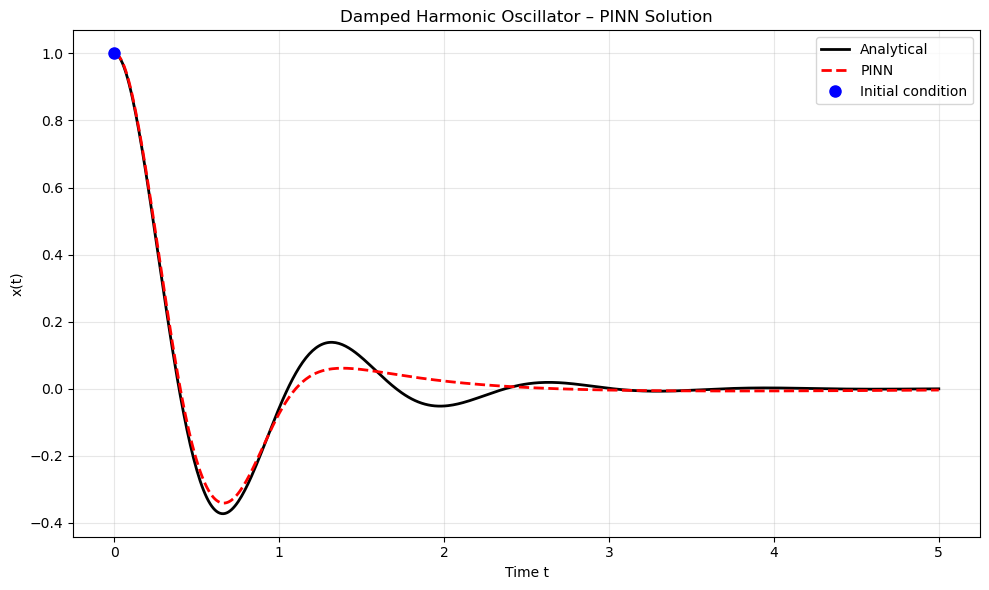

Relative L2 error: 1.44e-01


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t_np, x_exact, 'k-', lw=2, label='Analytical')
plt.plot(t_np, x_pred, 'r--', lw=2, label='PINN')
plt.plot(0, 1, 'bo', ms=8, label='Initial condition')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title('Damped Harmonic Oscillator – PINN Solution')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

error = np.linalg.norm(x_pred - x_exact) / np.linalg.norm(x_exact)
print(f"Relative L2 error: {error:.2e}")

Using device: cpu
Training pure neural network (only initial conditions)...

Epoch     1 → IC loss: 3.524e-07
Epoch    10 → IC loss: 3.524e-07
Epoch    20 → IC loss: 3.524e-07
Epoch    30 → IC loss: 3.524e-07
Epoch    40 → IC loss: 3.524e-07
Epoch    50 → IC loss: 3.524e-07
Epoch    60 → IC loss: 3.524e-07
Epoch    70 → IC loss: 3.524e-07
Epoch    80 → IC loss: 3.524e-07
Epoch    90 → IC loss: 3.524e-07
Epoch   100 → IC loss: 3.524e-07
Epoch   110 → IC loss: 3.524e-07
Epoch   120 → IC loss: 3.524e-07
Epoch   130 → IC loss: 3.524e-07
Epoch   140 → IC loss: 3.524e-07
Epoch   150 → IC loss: 3.524e-07
Epoch   160 → IC loss: 3.524e-07
Epoch   170 → IC loss: 3.524e-07
Epoch   180 → IC loss: 3.524e-07
Epoch   190 → IC loss: 3.524e-07
Epoch   200 → IC loss: 3.524e-07
Epoch   210 → IC loss: 3.524e-07
Epoch   220 → IC loss: 3.524e-07
Epoch   230 → IC loss: 3.524e-07
Epoch   240 → IC loss: 3.524e-07
Epoch   250 → IC loss: 3.524e-07
Epoch   260 → IC loss: 3.524e-07
Epoch   270 → IC loss: 3.524e-07

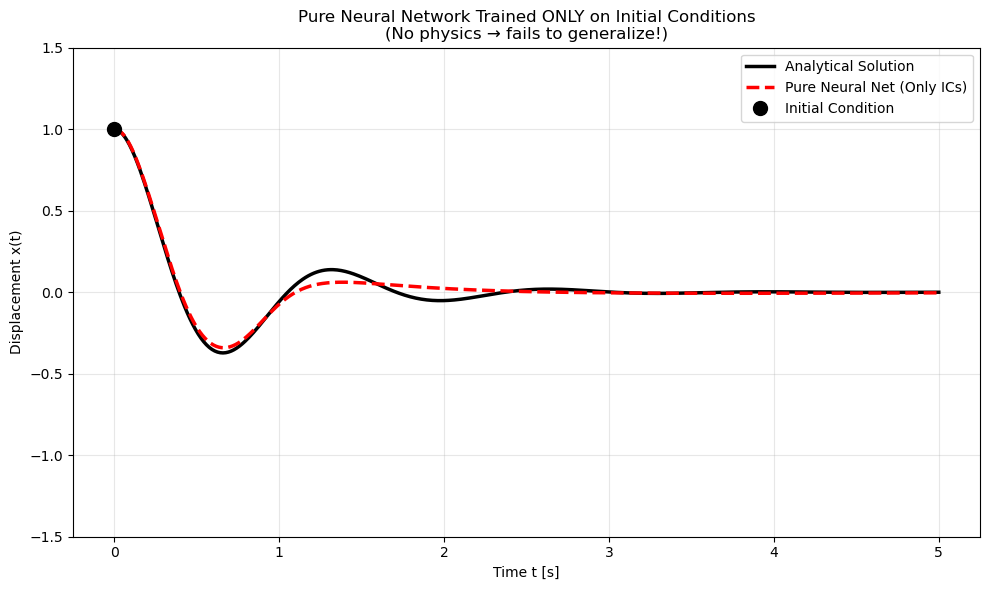

Relative L2 error: 1.44e-01


In [ ]:
# pure_neural_net_only_ic.py
# Pure data-driven neural network (NO physics) for damped oscillator
# Trained ONLY on x(0)=1 and v(0)=0 → shows why physics is crucial!

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -------------------------------
# Neural Network (same as PINN)
# -------------------------------
class PureNN(nn.Module):
    def __init__(self, layers=[1, 64, 64, 64, 64, 1]):
        super().__init__()
        self.net = nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers)-2:
                self.net.append(nn.Tanh())
    
    def forward(self, x):
        for layer in self.net:
            x = layer(x)
        return x

# -------------------------------
# Initial Condition Loss Only
# -------------------------------
def ic_loss(model):
    t0 = torch.zeros(1, 1, device=device, dtype=torch.float64, requires_grad=True)
    
    x0 = model(t0)                     # predicted position at t=0
    x0_t = torch.autograd.grad(x0, t0, torch.ones_like(x0),
                               create_graph=True, retain_graph=True)[0]  # velocity
    
    loss_position = (x0 - 1.0)**2        # x(0) = 1
    loss_velocity = (x0_t - 0.0)**2      # dx/dt(0) = 0
    return loss_position + loss_velocity


# -------------------------------
# Training
# -------------------------------
model_purenn = PureNN().to(device)
optimizer = torch.optim.Adam(model_purenn.parameters(), lr=1e-3)

epochs = 1000
print("Training pure neural network (only initial conditions)...\n")

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    loss = ic_loss(model)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d} → IC loss: {loss.item():.3e}")

print("\nTraining finished!\n")

# -------------------------------
# Evaluation & Plot
# -------------------------------
model_purenn.eval()
t_test = torch.linspace(0, 5, 600, device=device, dtype=torch.float64).unsqueeze(1)

with torch.no_grad():
    x_pred = model(t_test).cpu().numpy().flatten()

t_np = t_test.cpu().numpy().flatten()
x_exact = analytical(t_np)

plt.figure(figsize=(10, 6))
plt.plot(t_np, x_exact, 'k-', lw=2.5, label='Analytical Solution')
plt.plot(t_np, x_pred, 'r--', lw=2.5, label='Pure Neural Net (Only ICs)')
plt.plot(0, 1, 'ko', markersize=10, label='Initial Condition')
plt.xlabel('Time t [s]')
plt.ylabel('Displacement x(t)')
plt.title('Pure Neural Network Trained ONLY on Initial Conditions\n'
          '(No physics → fails to generalize!)')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.tight_layout()
plt.show()

error = np.linalg.norm(x_pred - x_exact) / np.linalg.norm(x_exact)
print(f"Relative L2 error: {error:.2e}")

In [ ]:
import torch
import torch.nn as nn
import numpy as np

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
import time

# Set default dtype to float64 for better precision in derivatives
torch.set_default_dtype(torch.float64)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [ ]:

# ==============================
# Run Training and Plot Results
# ==============================
if __name__ == "__main__":
    model = train_pinn()
    model.eval()
    
    # Test points
    t_test = torch.linspace(0, 5, 500).reshape(-1, 1).to(device)
    with torch.no_grad():
        x_pred = model(t_test).cpu().numpy().flatten()
    
    t_np = t_test.cpu().numpy().flatten()
    x_exact = analytical_solution(t_np)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(t_np, x_exact, 'k-', linewidth=2, label='Analytical Solution')
    plt.plot(t_np, x_pred, 'r--', linewidth=2, label='PINN Prediction')
    plt.scatter([0], [1.0], color='blue', zorder=5, label='Initial Condition')
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement x(t)')
    plt.title('Damped Harmonic Oscillator - PINN vs Analytical Solution\n'
              r'$\zeta=0.3$, $\omega_n=5$ rad/s, $x(0)=1$, $\dot{x}(0)=0$')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Compute L2 error
    error = np.linalg.norm(x_pred - x_exact) / np.linalg.norm(x_exact)
    print(f"Relative L2 error: {error:.3e}")

RuntimeError: One of the differentiated Tensors does not require grad

Training PINN on 100 points for 500 epochs...
Epoch      1 | ζ=0.19900 | ωₙ=2.99900 | loss=1.11e+01
Epoch      2 | ζ=0.19973 | ωₙ=2.99824 | loss=1.35e+01
Epoch      3 | ζ=0.20054 | ωₙ=2.99738 | loss=1.30e+01
Epoch      4 | ζ=0.20140 | ωₙ=2.99647 | loss=1.28e+01
Epoch      5 | ζ=0.20228 | ωₙ=2.99554 | loss=1.37e+01
Epoch      6 | ζ=0.20316 | ωₙ=2.99459 | loss=1.54e+01
Epoch      7 | ζ=0.20403 | ωₙ=2.99368 | loss=1.86e+01
Epoch      8 | ζ=0.20491 | ωₙ=2.99280 | loss=2.45e+01
Epoch      9 | ζ=0.20582 | ωₙ=2.99195 | loss=3.44e+01
Epoch     10 | ζ=0.20677 | ωₙ=2.99106 | loss=3.73e+01
Epoch     25 | ζ=0.22065 | ωₙ=2.97892 | loss=1.59e+01
Epoch     50 | ζ=0.24759 | ωₙ=2.95366 | loss=2.50e+01
Epoch     75 | ζ=0.27570 | ωₙ=2.92746 | loss=2.53e+01
Epoch    100 | ζ=0.29889 | ωₙ=2.90349 | loss=2.65e+01
Epoch    125 | ζ=0.32587 | ωₙ=2.87967 | loss=2.26e+01
Epoch    150 | ζ=0.35796 | ωₙ=2.85006 | loss=1.80e+01
Epoch    175 | ζ=0.38186 | ωₙ=2.82936 | loss=2.61e+01
Epoch    200 | ζ=0.41313 | ωₙ=2.8024

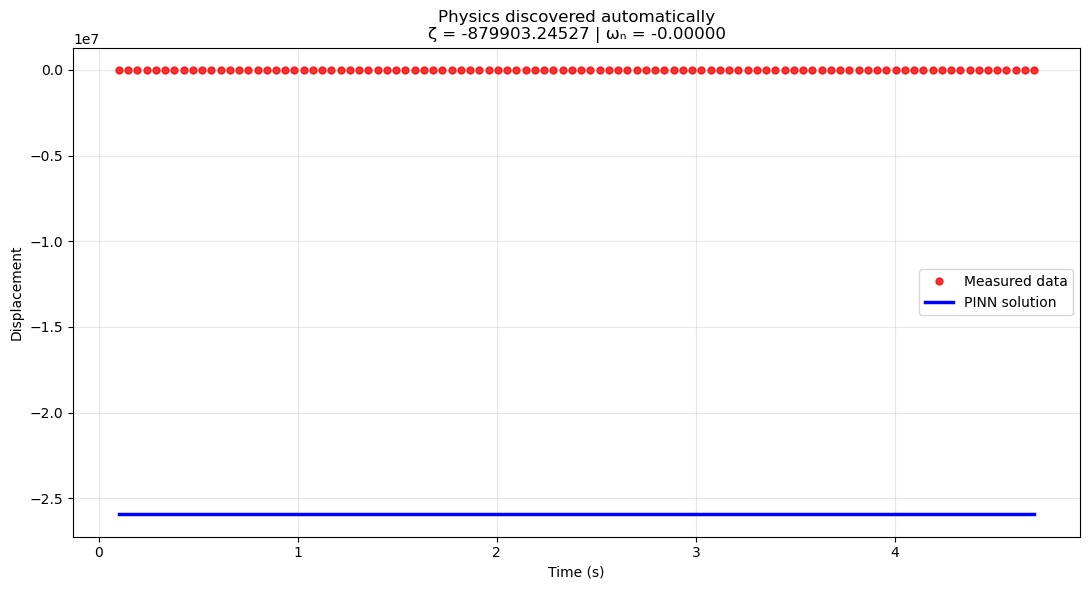

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def analytical(t, zeta=0.3, omega_n=5.0):
    wd = omega_n * np.sqrt(1 - zeta**2)
    return np.exp(-zeta*omega_n*t) * (np.cos(wd*t) + (zeta*omega_n/wd)*np.sin(wd*t))

def train_inverse_pinn_from_data(
    t_data,
    x_data,
    n_epochs=15000,
    colloc_points=8000,
    seed=42
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.set_default_dtype(torch.float64)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Convert data
    t_measured = torch.tensor(t_data, dtype=torch.float64).reshape(-1,1).to(device)
    x_measured = torch.tensor(x_data, dtype=torch.float64).reshape(-1,1).to(device)

    t_min, t_max = t_measured.min().item(), t_measured.max().item()

    # Model
    class InversePINN(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(1, 80), nn.Tanh(),
                nn.Linear(80, 80), nn.Tanh(),
                nn.Linear(80, 80), nn.Tanh(),
                nn.Linear(80, 1)
            )
            self.zeta    = nn.Parameter(0.2 * torch.ones(1))
            self.omega_n = nn.Parameter(3.0 * torch.ones(1))

        def forward(self, t):
            return self.net(t)

    model = InversePINN().to(device)

    # Losses
    def get_collocation(N=colloc_points):
        t = torch.rand(N, 1, device=device, dtype=torch.float64)
        return (t_min + (t_max - t_min) * t).requires_grad_(True)

    def pde_residual(t):
        t = t.clone().requires_grad_(True)
        x = model(t)
        x_t  = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
        x_tt = torch.autograd.grad(x_t, t, torch.ones_like(x_t), create_graph=True)[0]
        return x_tt + 2*model.zeta*model.omega_n*x_t + model.omega_n**2 * x

    def physics_loss():
        r = pde_residual(get_collocation())
        return torch.mean(r**2)

    def data_loss():
        pred = model(t_measured)
        return torch.mean((pred - x_measured)**2)

    def ic_loss():
        t0 = t_measured[0:1]
        x0 = model(t0)
        if len(t_measured) >= 2:
            dt = t_measured[1] - t_measured[0]
            v0 = (model(t_measured[1:2]) - x0) / dt
        else:
            v0 = torch.zeros_like(x0)
        return (x0 - x_measured[0])**2 + v0**2
    
    def total_loss():
        L_p = physics_loss()
        L_d = data_loss()
        L_i = ic_loss()

        # Adaptive weights WITHOUT .item() → graph stays intact!
        w_d = 1.0 / (L_d.detach() + 1e-12)   # detach = safe, keeps scalar
        w_i = 10.0 / (L_i.detach() + 1e-12)

        return L_p + w_d * L_d + w_i * L_i

    # Training
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    print(f"Training PINN on {len(t_data)} points for {n_epochs} epochs...")

    for epoch in range(1, n_epochs + 1):
        optimizer.zero_grad()
        loss = total_loss()
        loss.backward()
        optimizer.step()

        if epoch <= 10 or epoch % (max(n_epochs//20, 1)) == 0 or epoch == n_epochs:
            print(f"Epoch {epoch:6d} | ζ={model.zeta.item():.5f} | ωₙ={model.omega_n.item():.5f} | loss={loss.item():.2e}")

    print("Final LBFGS refinement...")
    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=0.1,
        max_iter=2000,
        tolerance_grad=1e-9,
        tolerance_change=1e-12,
        history_size=100
    )

    def closure():
        optimizer.zero_grad()
        loss = total_loss()
        loss.backward()
        return loss

    # Run a few LBFGS steps — usually 5–20 is enough
    for i in range(10):
        optimizer.step(closure)
        print(f"LBFGS step {i+1} | ζ={model.zeta.item():.7f} | ωₙ={model.omega_n.item():.7f}")

    print("LBFGS finished — solution preserved and polished!")

    # Results
    print("\n" + "="*60)
    print(f"FINAL → ζ = {model.zeta.item():.6f}  (true 0.300000)")
    print(f"FINAL → ωₙ = {model.omega_n.item():.6f}  (true 5.000000)")
    print("="*60)

    # Plot
    t_plot = torch.linspace(t_min, t_max, 600).reshape(-1,1).to(device)
    with torch.no_grad():
        x_pred = model(t_plot).cpu().numpy().flatten()

    plt.figure(figsize=(11,6))
    plt.plot(t_data, x_data, 'ro', label='Measured data', alpha=0.8, markersize=5)
    plt.plot(t_plot.cpu(), x_pred, 'b-', linewidth=2.5, label='PINN solution')
    plt.legend()
    plt.title(f"Physics discovered automatically\nζ = {model.zeta.item():.5f} | ωₙ = {model.omega_n.item():.5f}")
    plt.xlabel("Time (s)")
    plt.ylabel("Displacement")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return model

# =============================================================================
# Example usage — just change n_epochs!
# =============================================================================
if __name__ == "__main__":
    np.random.seed(42)
    t_ex = np.linspace(0.1, 4.7, 100)
    x_ex = analytical(t_ex, zeta=0.3, omega_n=5.0) + 0.05*np.random.randn(len(t_ex))

    # You control the number of epochs here:
    model = train_inverse_pinn_from_data(
        t_data=t_ex,
        x_data=x_ex,
        n_epochs=500        # ←←← change this to whatever you want
    )

Training PINN on 100 measured points for 200 epochs... (device=cpu)
Epoch      1 | loss=2.778e+01 | Lp=2.279e-01 | Ld=6.506e-02 | Li=2.690e+00 | ζ=0.20100 | ωₙ=2.99900
Epoch      2 | loss=2.677e+01 | Lp=1.112e-01 | Ld=6.179e-02 | Li=2.604e+00 | ζ=0.20031 | ωₙ=2.99807
Epoch      3 | loss=2.584e+01 | Lp=5.442e-02 | Ld=5.926e-02 | Li=2.519e+00 | ζ=0.19948 | ωₙ=2.99724
Epoch      4 | loss=2.497e+01 | Lp=4.752e-02 | Ld=5.740e-02 | Li=2.435e+00 | ζ=0.19868 | ωₙ=2.99646
Epoch      5 | loss=2.417e+01 | Lp=9.103e-02 | Ld=5.616e-02 | Li=2.351e+00 | ζ=0.19858 | ωₙ=2.99566
Epoch      6 | loss=2.341e+01 | Lp=1.842e-01 | Ld=5.555e-02 | Li=2.267e+00 | ζ=0.19901 | ωₙ=2.99480
Epoch      7 | loss=2.269e+01 | Lp=3.183e-01 | Ld=5.555e-02 | Li=2.182e+00 | ζ=0.19964 | ωₙ=2.99391
Epoch      8 | loss=2.203e+01 | Lp=5.192e-01 | Ld=5.620e-02 | Li=2.095e+00 | ζ=0.20037 | ωₙ=2.99302
Epoch      9 | loss=2.140e+01 | Lp=7.518e-01 | Ld=5.751e-02 | Li=2.008e+00 | ζ=0.20115 | ωₙ=2.99212
Epoch     10 | loss=2.085e+01 | 

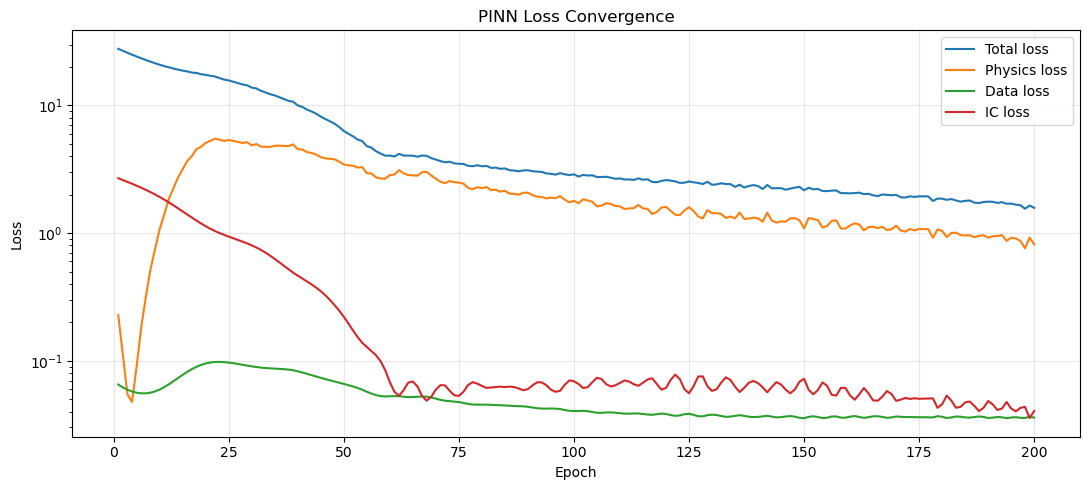

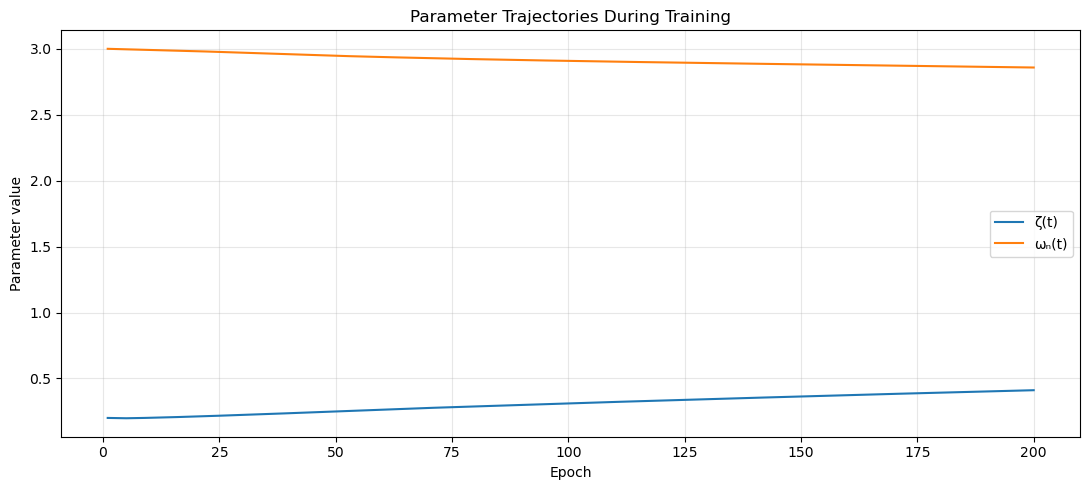

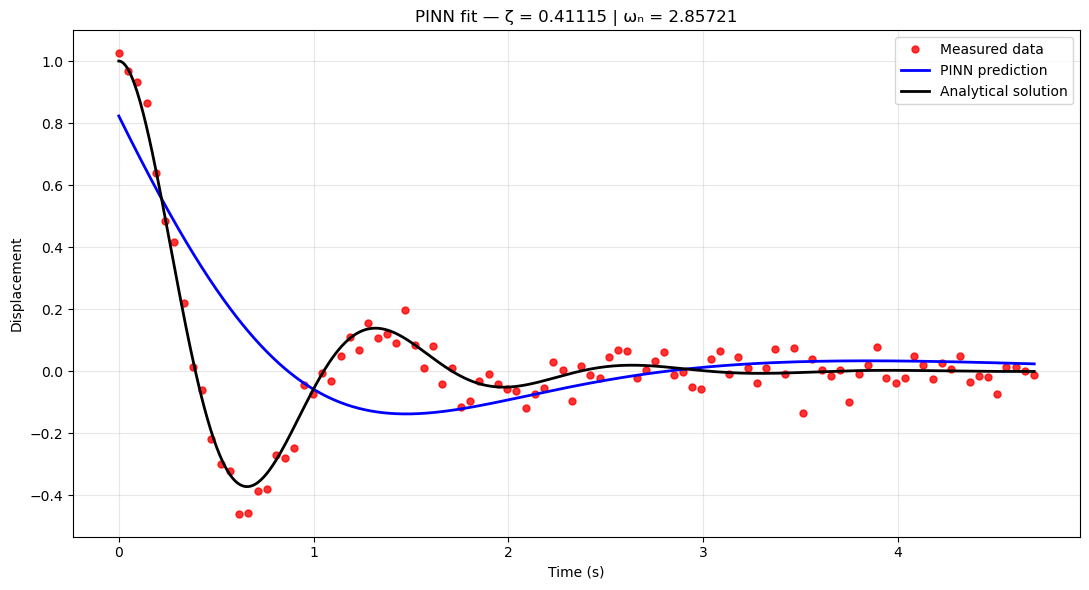

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Analytical reference (to produce the mock data)
# ---------------------------
def analytical(t, zeta=0.3, omega_n=5.0):
    wd = omega_n * np.sqrt(1 - zeta**2)
    return np.exp(-zeta*omega_n*t) * (np.cos(wd*t) + (zeta*omega_n/wd)*np.sin(wd*t))

# ---------------------------
# Diagnostics helper
# ---------------------------
class DiagnosticsLogger:
    def __init__(self):
        self.history = {
            "epoch": [],
            "L_total": [],
            "L_phys": [],
            "L_data": [],
            "L_ic": [],
            "zeta": [],
            "omega_n": []
        }

    def record(self, epoch, total, Lp, Ld, Li, zeta, omega):
        self.history["epoch"].append(epoch)
        self.history["L_total"].append(total)
        self.history["L_phys"].append(Lp)
        self.history["L_data"].append(Ld)
        self.history["L_ic"].append(Li)
        self.history["zeta"].append(zeta)
        self.history["omega_n"].append(omega)

    def plot_all(self):
        h = self.history
        # Losses (log scale)
        plt.figure(figsize=(11,5))
        plt.plot(h["epoch"], h["L_total"], label="Total loss")
        plt.plot(h["epoch"], h["L_phys"], label="Physics loss")
        plt.plot(h["epoch"], h["L_data"], label="Data loss")
        plt.plot(h["epoch"], h["L_ic"], label="IC loss")
        plt.yscale("log")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("PINN Loss Convergence")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Parameter trajectories
        plt.figure(figsize=(11,5))
        plt.plot(h["epoch"], h["zeta"], label="ζ(t)")
        plt.plot(h["epoch"], h["omega_n"], label="ωₙ(t)")
        plt.xlabel("Epoch")
        plt.ylabel("Parameter value")
        plt.title("Parameter Trajectories During Training")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# ---------------------------
# Model definition (smaller, SiLU activation)
# ---------------------------
class InversePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )
        self.zeta    = nn.Parameter(torch.tensor([0.2], dtype=torch.float64))
        self.omega_n = nn.Parameter(torch.tensor([3.0], dtype=torch.float64))

    def forward(self, t_hat):
        return self.net(t_hat)
        
# ---------------------------
# Main training function (corrected)
# ---------------------------
def train_inverse_pinn_from_data(
    t_data,
    x_data,
    n_epochs=2000,
    colloc_points=8000,
    seed=42,
    use_lbfgs=True,
):
    # reproducibility and dtype
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.set_default_dtype(torch.float64)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # convert to tensors (raw, physical time)
    t_raw = torch.tensor(np.asarray(t_data).reshape(-1,1), dtype=torch.float64, device=device)
    x_measured = torch.tensor(np.asarray(x_data).reshape(-1,1), dtype=torch.float64, device=device)

    # store physical bounds for rescaling back and for derivative scaling
    t_min = float(t_raw.min().item())
    t_max = float(t_raw.max().item())
    if t_max == t_min:
        raise ValueError("t_data has zero range")

    # Normalise time to t_hat in [-1, 1]
    def to_t_hat(t_phys):
        return 2.0 * (t_phys - t_min) / (t_max - t_min) - 1.0

    def to_t_phys(t_hat):
        return (t_hat + 1.0) * 0.5 * (t_max - t_min) + t_min

    t_measured = to_t_hat(t_raw).detach()  # shape (N,1), does not need grad for data loss
    # dt_scale: d/dt_phys = dt_scale * d/dt_hat
    dt_scale = 2.0 / (t_max - t_min)



    model = InversePINN().to(device)

    # ---------------------------
    # Collocation sampling in t_hat space [-1,1]
    # ---------------------------
    def get_collocation(N=colloc_points):
        t = torch.rand(N, 1, device=device, dtype=torch.float64) * 2.0 - 1.0
        return t.requires_grad_(True)

    # ---------------------------
    # PDE residual with correct derivative scaling
    # x_tt + 2*zeta*omega_n*x_t + omega_n^2 * x = 0
    # where derivatives computed w.r.t. physical time using dt_scale
    # ---------------------------
    def pde_residual(t_hat):
        # t_hat should require_grad
        t_hat = t_hat.clone().requires_grad_(True)
        x = model(t_hat)                               # x(t_hat)
        dx_dthat = torch.autograd.grad(x, t_hat, torch.ones_like(x), create_graph=True)[0]
        d2x_dthat2 = torch.autograd.grad(dx_dthat, t_hat, torch.ones_like(dx_dthat), create_graph=True)[0]

        # convert to physical derivatives
        x_t_phys  = dt_scale * dx_dthat
        x_tt_phys = (dt_scale**2) * d2x_dthat2

        return x_tt_phys + 2.0 * model.zeta * model.omega_n * x_t_phys + (model.omega_n**2) * x

    # ---------------------------
    # Loss components
    # ---------------------------
    def physics_loss():
        t_colloc = get_collocation()
        r = pde_residual(t_colloc)
        return torch.mean(r**2)

    def data_loss():
        # We evaluate model on normalized measured times
        pred = model(t_measured)
        return torch.mean((pred - x_measured)**2)

    def ic_loss():
        # Use autograd at the first measured point to compute model derivative in physical time,
        # and compare to measured finite-difference velocity.
        # (Assumes at least two measured points exist.)
        t0_phys = t_raw[0:1]                      # physical time (shape (1,1))
        t1_phys = t_raw[1:2] if t_raw.shape[0] >= 2 else t_raw[0:1] + 1e-6
        x0_meas = x_measured[0:1]
        x1_meas = x_measured[1:2] if x_measured.shape[0] >= 2 else x_measured[0:1]

        # finite-difference estimate of initial velocity (physical)
        dt_phys = float((t1_phys - t0_phys).cpu().numpy().flatten()[0])
        if dt_phys == 0:
            v0_true = torch.zeros_like(x0_meas, device=device)
        else:
            v0_true = (x1_meas - x0_meas) / dt_phys

        # compute model derivative at t0 (use normalized coordinate for autograd)
        t0_hat = to_t_hat(t0_phys).clone().requires_grad_(True).to(device)
        x0_pred = model(t0_hat)
        dx_dthat = torch.autograd.grad(x0_pred, t0_hat, torch.ones_like(x0_pred), create_graph=True)[0]
        x_t0_pred_phys = dt_scale * dx_dthat

        # enforce both displacement and velocity at t0
        return torch.mean((x0_pred - x0_meas)**2) + torch.mean((x_t0_pred_phys - v0_true)**2)

    # ---------------------------
    # Total loss - use fixed weights (stable)
    # ---------------------------
    def total_loss():
        Lp = physics_loss()
        Ld = data_loss()
        Li = ic_loss()
        # fixed weights (tune if needed)
        w_d = 10.0
        w_i = 10.0
        return Lp + w_d * Ld + w_i * Li, Lp, Ld, Li

    # ---------------------------
    # Training
    # ---------------------------
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    diag = DiagnosticsLogger()
    print(f"Training PINN on {t_raw.shape[0]} measured points for {n_epochs} epochs... (device={device})")

    for epoch in range(1, n_epochs + 1):
        optimizer.zero_grad()
        loss_total, Lp, Ld, Li = total_loss()
        loss_total.backward()
        optimizer.step()

        # record diagnostics
        diag.record(epoch, float(loss_total.item()), float(Lp.item()), float(Ld.item()), float(Li.item()),
                    float(model.zeta.item()), float(model.omega_n.item()))

        # print occasionally
        if epoch <= 10 or epoch % max(1, n_epochs // 20) == 0 or epoch == n_epochs:
            print(f"Epoch {epoch:6d} | loss={loss_total.item():.3e} | Lp={Lp.item():.3e} | Ld={Ld.item():.3e} | Li={Li.item():.3e} | ζ={model.zeta.item():.5f} | ωₙ={model.omega_n.item():.5f}")

    # ---------------------------
    # Optional LBFGS refinement (keeps autodiff graph usage consistent)
    # ---------------------------
    if use_lbfgs:
        print("Refining with LBFGS...")
        lbfgs_opt = torch.optim.LBFGS(model.parameters(), lr=0.2, max_iter=500, tolerance_grad=1e-9, tolerance_change=1e-12, history_size=50)

        def closure():
            lbfgs_opt.zero_grad()
            loss_total, Lp, Ld, Li = total_loss()
            loss_total.backward()
            return loss_total

        # run several steps
        for i in range(8):
            lbfgs_opt.step(closure)
            loss_total, Lp, Ld, Li = total_loss()
            print(f" LBFGS step {i+1:2d} | loss={loss_total.item():.3e} | ζ={model.zeta.item():.7f} | ωₙ={model.omega_n.item():.7f}")
            # record LBFGS steps in diagnostics too
            diag.record(n_epochs + i + 1, float(loss_total.item()), float(Lp.item()), float(Ld.item()), float(Li.item()),
                        float(model.zeta.item()), float(model.omega_n.item()))

    print("Training finished.\n")
    print(f"Final parameters: ζ = {model.zeta.item():.6f}  (true 0.300000), ωₙ = {model.omega_n.item():.6f}  (true 5.000000)")

    # ---------------------------
    # Diagnostics plots
    # ---------------------------
    print("\nGenerating diagnostics plots...")
    diag.plot_all()

    # ---------------------------
    # Plot fit vs data (on physical time)
    # ---------------------------
    t_plot_phys = np.linspace(t_min, t_max, 600).reshape(-1,1)
    t_plot_hat = to_t_hat(torch.tensor(t_plot_phys, dtype=torch.float64, device=device)).reshape(-1,1)
    with torch.no_grad():
        x_pred = model(t_plot_hat).cpu().numpy().flatten()

    x_analytical=analytical(t_plot_phys)
    plt.figure(figsize=(11,6))
    plt.plot(t_raw.cpu().numpy().flatten(), x_measured.cpu().numpy().flatten(), 'ro', label='Measured data', alpha=0.8, markersize=5)
    plt.plot(t_plot_phys.flatten(), x_pred, 'b-', linewidth=2.0, label='PINN prediction')
    plt.plot(t_plot_phys.flatten(), x_analytical, 'black', linewidth=2.0, label='Analytical solution')
    plt.xlabel("Time (s)")
    plt.ylabel("Displacement")
    plt.title(f"PINN fit — ζ = {model.zeta.item():.5f} | ωₙ = {model.omega_n.item():.5f}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return model, diag

# ---------------------------
# Example: run as script
# ---------------------------
if __name__ == "__main__":
    np.random.seed(42)
    # I recommend starting at t=0 so IC is meaningful for a physical initial condition
    t_ex = np.linspace(0.0, 4.7, 100)
    x_ex = analytical(t_ex, zeta=0.3, omega_n=5.0) + 0.05 * np.random.randn(len(t_ex))

    model, diag = train_inverse_pinn_from_data(
        t_data=t_ex,
        x_data=x_ex,
        n_epochs=8000,      # increase if still underfitting (try 3k-10k)
        colloc_points=8000,
        seed=42,
        use_lbfgs=False
    )
